<a href="https://colab.research.google.com/github/DeepthiManthapuram/Deep_Learning/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
from tensorflow.keras.datasets import mnist
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np


In [33]:
#Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

#Display dataset shapes
print(f"x_train shape: {x_train.shape}")
print(f"x_train shape: {y_train.shape}")
print(f"x_train shape: {x_test.shape}")
print(f"x_train shape: {y_test.shape}")

x_train shape: (60000, 28, 28)
x_train shape: (60000,)
x_train shape: (10000, 28, 28)
x_train shape: (10000,)


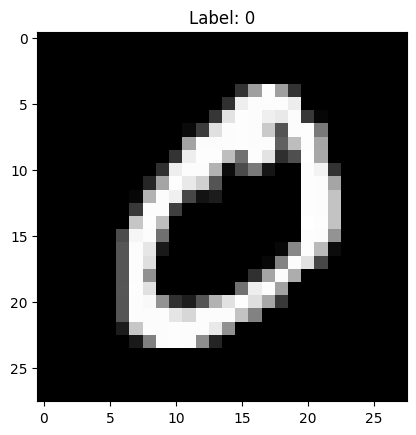

In [34]:
#Basic Data Visualization
img = x_train[1,:,:]
label = y_train[1]
plt.imshow(img, cmap = 'gray')
plt.title(f"Label: {label}")
plt.show()

**Data Preprocessing**

Normalize the data and reshape it for CNN input

In [35]:
from keras.src.utils import to_categorical
#normalize and reshape
x_train = x_train.reshape(-1,28,28,1).astype('float32')/255
x_test = x_test.reshape(-1, 28, 28, 1).astype('float')/255

#one - hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

**Model Building**

Build a CNN model using keras Sequential API

In [36]:
model = Sequential([
    Conv2D(32,kernel_size = (3, 3), activation = 'relu', input_shape = (28, 28, 1)),    #convolution layer - detect patterns
    MaxPooling2D(pool_size=(2, 2)), #Pooling layer - reduces spatial dimensions
    Conv2D(64, kernel_size=(3, 3), activation='relu'), #Convlution layer - detects patterns
    MaxPooling2D(pool_size=(2, 2)), #Pooling layer - reduces spatial dimensions
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(10, activation = 'softmax')
    ])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

**Model Training**
Train the model on the training data

In [38]:

history = model.fit(x_train, y_train, epochs = 5, batch_size = 128, validation_split=0.2)
#epochs -> model sees dataset 5 times
#batch_size -> processes 128 images per step
#validation_split -> uses 20% of training data fro validation

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8421 - loss: 0.5400 - val_accuracy: 0.9762 - val_loss: 0.0830
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9782 - loss: 0.0698 - val_accuracy: 0.9837 - val_loss: 0.0559
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9866 - loss: 0.0435 - val_accuracy: 0.9858 - val_loss: 0.0487
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9898 - loss: 0.0321 - val_accuracy: 0.9868 - val_loss: 0.0458
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9924 - loss: 0.0244 - val_accuracy: 0.9887 - val_loss: 0.0375


**Model Evaluation**

In [39]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9866 - loss: 0.0413
Test loss: 0.0326664075255394
Test accuracy: 0.9898999929428101


**Prediction**
Make predictions on new data samples

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


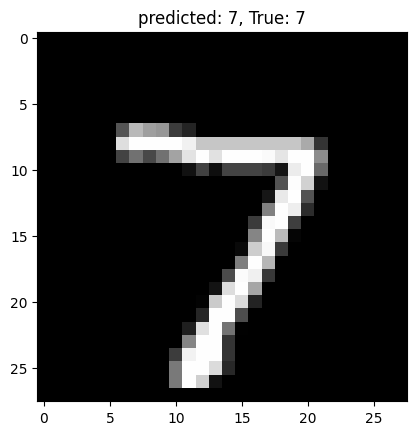

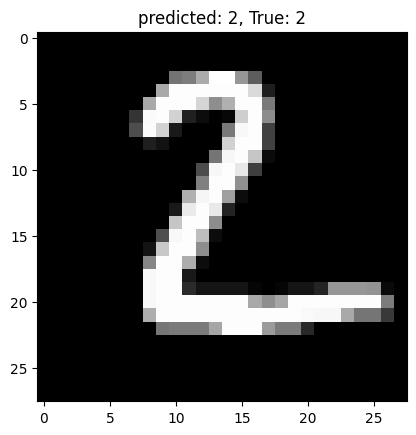

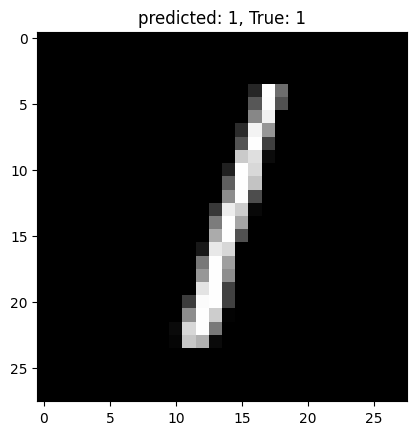

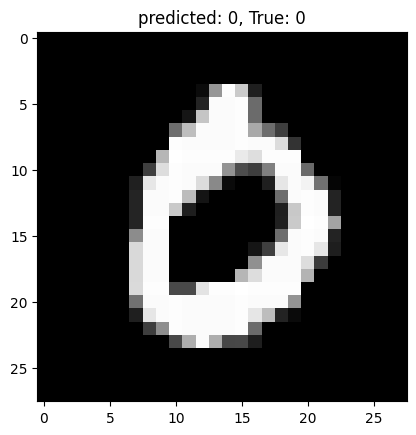

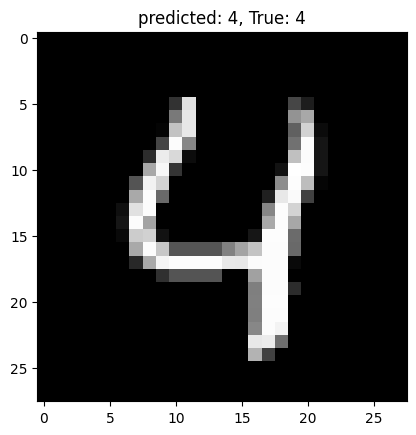

In [41]:
#predict on the few test samples
predictions = model.predict(x_test[:5])
predicted_classes = np.argmax(predictions, axis = 1)
true_classes = np.argmax(y_test[:5], axis = 1)

for i in range(5):
  plt.imshow(x_test[i].reshape(28, 28), cmap = 'gray')
  plt.title(f"predicted: {predicted_classes[i]}, True: {true_classes[i]}")
  plt.show()